## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [10]:
pip install yfinance

  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.0.5-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached yfinance-1.3.0-py2.py3-none-any.whl (133 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.5-py3-none-any.whl (144 kB)
Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl (437 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)

   ----------------------------------------  0/15 [pytz]
   ----------------------------------------  0/15 [


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Dev\causal(2026)\.venv\Scripts\python.exe -m pip install --upgrade pip


In [11]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [17]:
# 구글 주식 데이터 로딩
goog = yf.download("INTC", start="2020-01-01", end="2026-04-28")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
Date,,,,,
2020-01-02,53.666473,53.781146,53.119577,53.137220,18056000
2020-01-03,53.013718,53.542975,52.757914,52.757914,15293900
2020-01-06,52.863773,53.101939,52.334519,52.563862,17755200
2020-01-07,51.981674,52.749093,51.946390,52.731451,21876100
2020-01-08,52.016956,52.325687,51.620014,51.946387,23133500


In [28]:
# [+] 종가(Close) 데이터만 사용하기
goog = goog['INTC']
goog

Date
2020-01-02    53.666473
2020-01-03    53.013718
2020-01-06    52.863773
2020-01-07    51.981674
2020-01-08    52.016956
                ...    
2026-04-21    66.260002
2026-04-22    65.269997
2026-04-23    66.779999
2026-04-24    82.540001
2026-04-27    84.989998
Name: INTC, Length: 1587, dtype: float64

<Axes: xlabel='Date'>

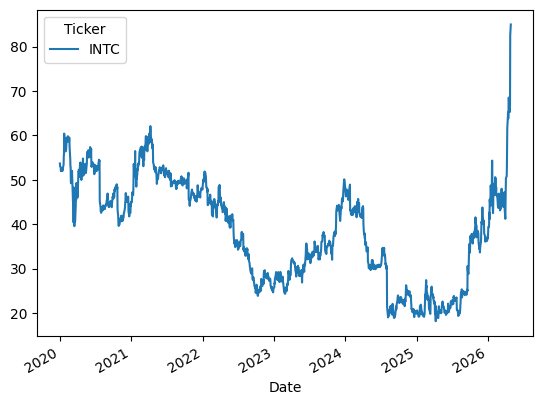

In [24]:
# [+] Lineplot 시각화
goog.plot()

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [31]:
# [+] 다운샘플링: resample()
goog_downsampled = goog.resample('ME').mean()
goog_downsampled

Date
2020-01-31    54.564942
2020-02-29    56.958799
2020-03-31    46.209496
2020-04-30    51.777562
2020-05-31    53.618139
                ...    
2025-12-31    38.544545
2026-01-31    45.798000
2026-02-28    46.973158
2026-03-31    44.891363
2026-04-30    63.756667
Freq: ME, Name: INTC, Length: 76, dtype: float64

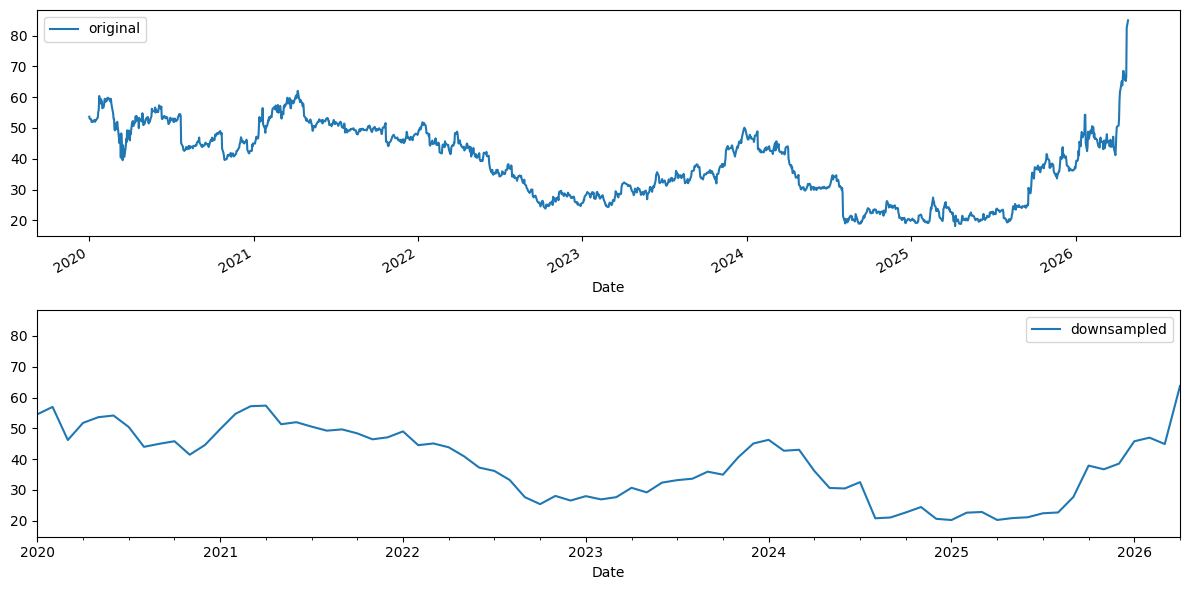

In [32]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()

Date
2020-01-31    56.392124
2020-02-29          NaN
2020-03-31    47.973904
2020-04-30    53.168434
2020-05-31          NaN
                ...    
2025-11-30          NaN
2025-12-31    36.900002
2026-01-31          NaN
2026-02-28          NaN
2026-03-31    44.130001
Freq: ME, Name: INTC, Length: 75, dtype: float64


<Axes: xlabel='Date'>

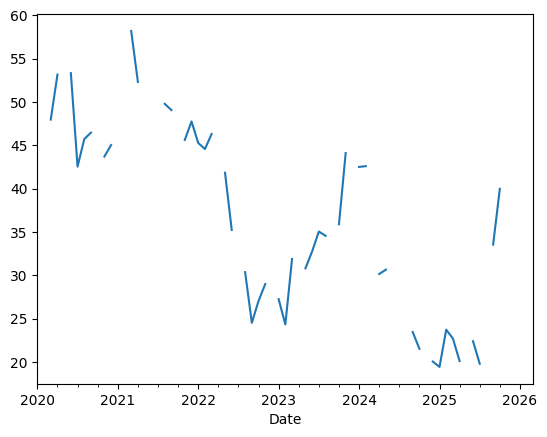

In [33]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('ME')
print(goog_downsampled)

goog_downsampled.plot()

In [34]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample('12h').mean()
print(goog_upsampled)

Date
2020-01-02 00:00:00    53.666473
2020-01-02 12:00:00          NaN
2020-01-03 00:00:00    53.013718
2020-01-03 12:00:00          NaN
2020-01-04 00:00:00          NaN
                         ...    
2026-04-25 00:00:00          NaN
2026-04-25 12:00:00          NaN
2026-04-26 00:00:00          NaN
2026-04-26 12:00:00          NaN
2026-04-27 00:00:00    84.989998
Freq: 12h, Name: INTC, Length: 4615, dtype: float64


#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [45]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shift(periods = -900)
goog_shifted

Date
2020-01-02    35.084869
2020-01-03    33.703033
2020-01-06    34.173447
2020-01-07    34.561951
2020-01-08    34.650467
                ...    
2026-04-21          NaN
2026-04-22          NaN
2026-04-23          NaN
2026-04-24          NaN
2026-04-27          NaN
Name: INTC, Length: 1587, dtype: float64

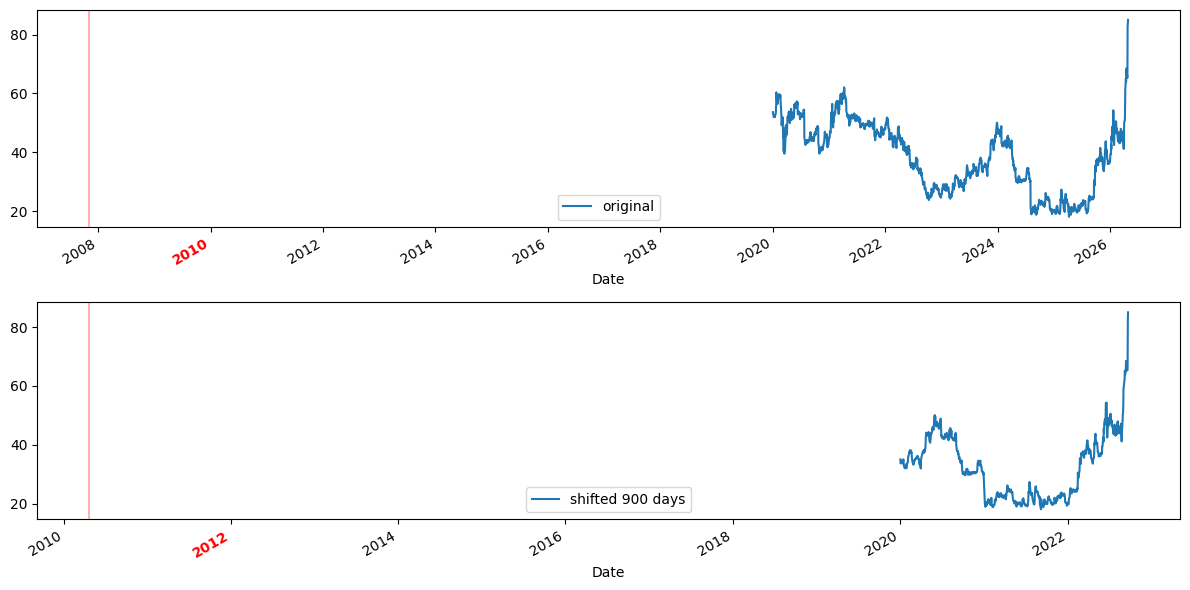

In [46]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [50]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods = 1) # [+] 시프팅
(goog - goog_shifted) / goog_shifted # [+] 주가 변화율 계산

Date
2020-01-02         NaN
2020-01-03   -0.012163
2020-01-06   -0.002828
2020-01-07   -0.016686
2020-01-08    0.000679
                ...   
2026-04-21    0.008524
2026-04-22   -0.014941
2026-04-23    0.023135
2026-04-24    0.235999
2026-04-27    0.029683
Name: INTC, Length: 1587, dtype: float64

Date
2020-01-02          NaN
2020-01-03    -0.652756
2020-01-06    -0.149944
2020-01-07    -0.882099
2020-01-08     0.035282
                ...    
2026-04-21     0.560005
2026-04-22    -0.990005
2026-04-23     1.510002
2026-04-24    15.760002
2026-04-27     2.449997
Name: INTC, Length: 1587, dtype: float64


<Axes: xlabel='Date'>

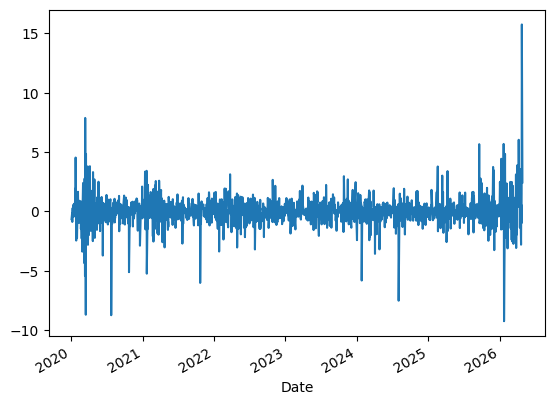

In [52]:
# shifting 응용: 차분 시계열 구하기
goog_diff = goog - goog_shifted  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

In [ ]:
# [+] 365일 단위 윈도잉
goog_rolled = ...
print(goog_rolled)

goog_rolled.mean().plot()

In [ ]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)